# NB03 – Data Analysis

## European Air Quality and Weather

### Research question

How does air quality vary across major European cities, and which weather conditions are associated with worse pollution?

### Purpose

This notebook analyzes the processed dataset created in NB02. It compares air quality across ten European cities and explores whether temperature, humidity, pressure, and wind speed are associated with pollution levels.

The data represents a snapshot collected at one point in time. Therefore, the results show patterns within this sample but do not establish causal relationships.

## Import the packages 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## Define the project paths

In [2]:
PROJECT_DIR = Path("..")

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "docs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load the processed dataset

In [3]:
data_file = PROCESSED_DATA_DIR / "air_quality_weather_clean.csv"

df = pd.read_csv(data_file)

df.head()

,city,country,collection_time,latitude,longitude,aqi,aqi_category,pm2_5,pm10,no2,o3,co,temperature_c,humidity_percent,pressure_hpa,wind_speed_ms
0,London,GB,2026-07-30T15:39:05.094096+00:00,51.5074,-0.1278,2,Fair,6.21,14.71,5.14,88.45,96.55,27.75,45,1014,1.79
1,Paris,FR,2026-07-30T15:39:05.179592+00:00,48.8566,2.3522,3,Moderate,8.87,9.97,0.76,106.30,116.18,30.24,51,1015,3.01
2,Berlin,DE,2026-07-30T15:39:05.263652+00:00,52.5200,13.4050,3,Moderate,4.79,5.53,3.00,123.64,101.60,37.23,21,1009,3.58
3,Madrid,ES,2026-07-30T15:39:05.353611+00:00,40.4168,-3.7038,3,Moderate,18.97,77.85,0.20,86.31,91.82,37.48,17,1015,0.89
4,Rome,IT,2026-07-30T15:39:05.443955+00:00,41.9028,12.4964,3,Moderate,11.66,22.97,0.35,117.59,170.53,36.16,33,1015,2.68


## Initial data checks

Before analyzing the data, the dataset is checked to confirm its dimensions, column names, data types, and missing values.

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Shape: (10, 16)

Columns:
['city', 'country', 'collection_time', 'latitude', 'longitude', 'aqi', 'aqi_category', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_ms']

Missing values:
city                0
country             0
collection_time     0
latitude            0
longitude           0
aqi                 0
aqi_category        0
pm2_5               0
pm10                0
no2                 0
o3                  0
co                  0
temperature_c       0
humidity_percent    0
pressure_hpa        0
wind_speed_ms       0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              10 non-null     object 
 1   country           10 non-null     object 
 2   collection_time   10 non-null     object 
 3   latitude          10 non-null     float64
 4   longitude         10 non-null     float64
 5   aqi               10 non-null     int64  
 6   aqi_category      10 non-null     object 
 7   pm2_5             10 non-null     float64
 8   pm10              10 non-null     float64
 9   no2               10 non-null     float64
 10  o3                10 non-null     float64
 11  co                10 non-null     float64
 12  temperature_c     10 non-null     float64
 13  humidity_percent  10 non-null     int64  
 14  pressure_hpa      10 non-null     int64  
 15  wind_speed_ms     10 non-null     float64
dtypes: float64(9), int64(3), object(4)
memory usage

## Get a summary of the statistics

In [6]:
summary_columns = [
    "aqi",
    "pm2_5",
    "pm10",
    "no2",
    "o3",
    "co",
    "temperature_c",
    "humidity_percent",
    "pressure_hpa",
    "wind_speed_ms"
]

df[summary_columns].describe().round(2)

,aqi,pm2_5,pm10,no2,o3,co,temperature_c,humidity_percent,pressure_hpa,wind_speed_ms
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,2.80,9.25,18.12,2.85,105.62,114.02,31.18,42.40,1014.00,2.59
std,0.42,4.31,21.64,2.51,13.53,24.10,5.52,20.86,2.26,1.47
min,2.00,3.72,4.37,0.20,86.31,91.82,22.23,17.00,1009.00,0.89
25%,3.00,6.56,8.77,0.88,95.56,97.81,28.06,24.00,1014.00,1.14
50%,3.00,9.06,11.38,2.24,105.62,106.98,30.62,42.00,1015.00,2.68
75%,3.00,10.83,14.70,4.60,115.50,122.34,36.38,50.75,1015.00,3.44
max,3.00,18.97,77.85,7.01,123.94,170.53,37.48,83.00,1016.00,4.74


The summary statistics show the range and average of the air-quality and weather measurements. These values are used to identify variation between cities and check for unusually high or low observations.

## Finding 1: Air Quality Index across cities

The first chart compares the OpenWeather Air Quality Index category for each city. Higher AQI values represent worse overall air quality.

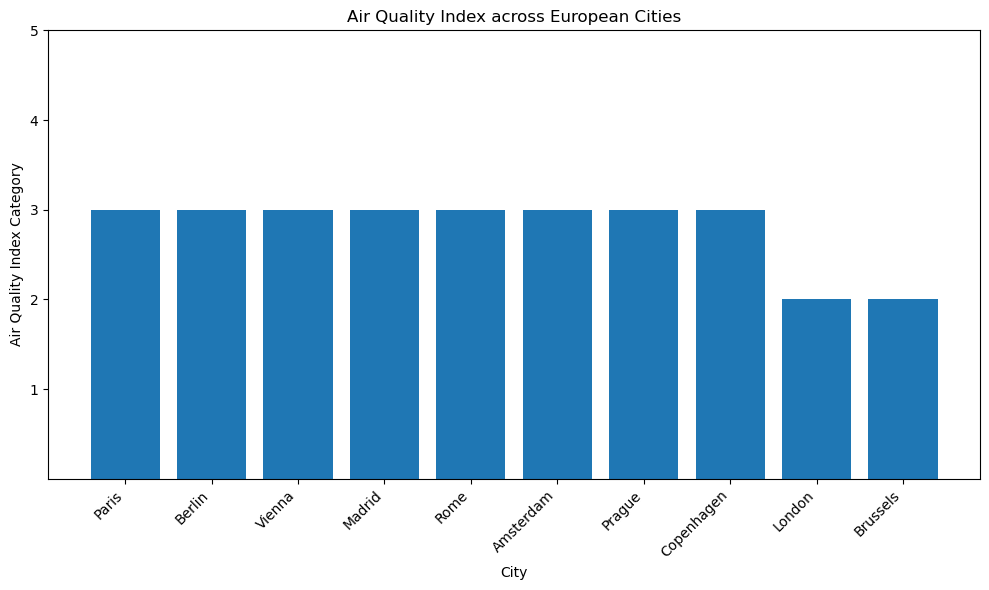

In [7]:
aqi_sorted = df.sort_values("aqi", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    aqi_sorted["city"],
    aqi_sorted["aqi"]
)

plt.title("Air Quality Index across European Cities")
plt.xlabel("City")
plt.ylabel("Air Quality Index Category")
plt.xticks(rotation=45, ha="right")
plt.yticks([1, 2, 3, 4, 5])
plt.tight_layout()

aqi_figure = FIGURES_DIR / "aqi_by_city.png"
plt.savefig(aqi_figure, dpi=300, bbox_inches="tight")

plt.show()

In [8]:
aqi_sorted[
    ["city", "aqi", "aqi_category"]
]

,city,aqi,aqi_category
1,Paris,3,Moderate
2,Berlin,3,Moderate
7,Vienna,3,Moderate
3,Madrid,3,Moderate
4,Rome,3,Moderate
5,Amsterdam,3,Moderate
9,Prague,3,Moderate
8,Copenhagen,3,Moderate
0,London,2,Fair
6,Brussels,2,Fair


## Finding 2: Fine-particle pollution across cities

PM2.5 measures very small airborne particles. Unlike the five-category AQI measure, PM2.5 concentrations provide a more detailed comparison between cities.

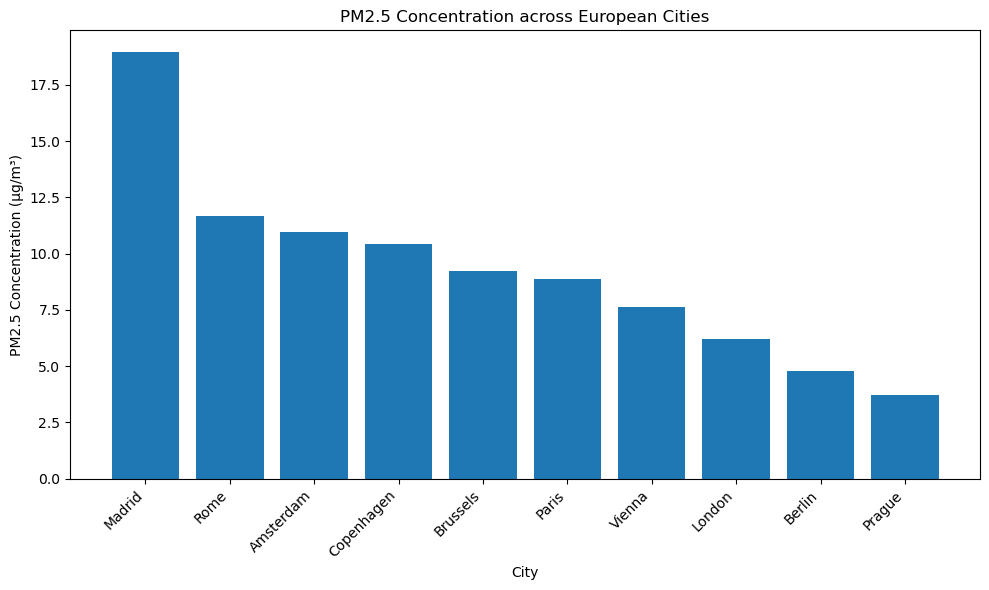

In [9]:
pm25_sorted = df.sort_values("pm2_5", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    pm25_sorted["city"],
    pm25_sorted["pm2_5"]
)

plt.title("PM2.5 Concentration across European Cities")
plt.xlabel("City")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

pm25_figure = FIGURES_DIR / "pm25_by_city.png"
plt.savefig(pm25_figure, dpi=300, bbox_inches="tight")

plt.show()

In [10]:
pm25_sorted[
    ["city", "pm2_5", "aqi_category"]
].reset_index(drop=True)

,city,pm2_5,aqi_category
0,Madrid,18.97,Moderate
1,Rome,11.66,Moderate
2,Amsterdam,10.96,Moderate
3,Copenhagen,10.43,Moderate
4,Brussels,9.24,Fair
5,Paris,8.87,Moderate
6,Vienna,7.62,Moderate
7,London,6.21,Fair
8,Berlin,4.79,Moderate
9,Prague,3.72,Moderate


## PM10 comparison

PM10 measures larger airborne particles. Comparing PM10 and PM2.5 helps determine whether cities with high fine particle pollution also have high levels of larger particles.

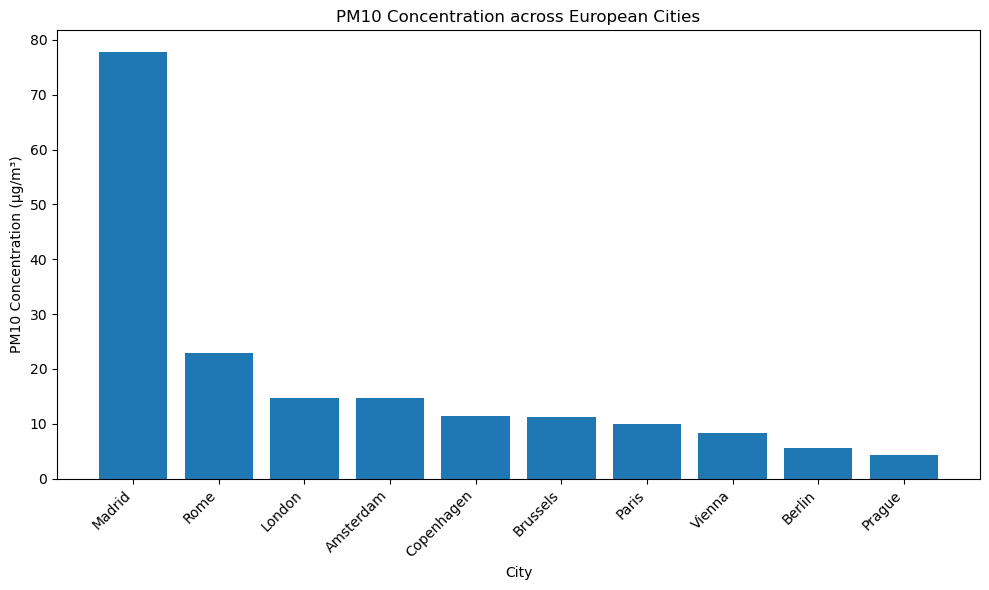

In [11]:
pm10_sorted = df.sort_values("pm10", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    pm10_sorted["city"],
    pm10_sorted["pm10"]
)

plt.title("PM10 Concentration across European Cities")
plt.xlabel("City")
plt.ylabel("PM10 Concentration (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

pm10_figure = FIGURES_DIR / "pm10_by_city.png"
plt.savefig(pm10_figure, dpi=300, bbox_inches="tight")

plt.show()

## Comparing PM2.5 and PM10

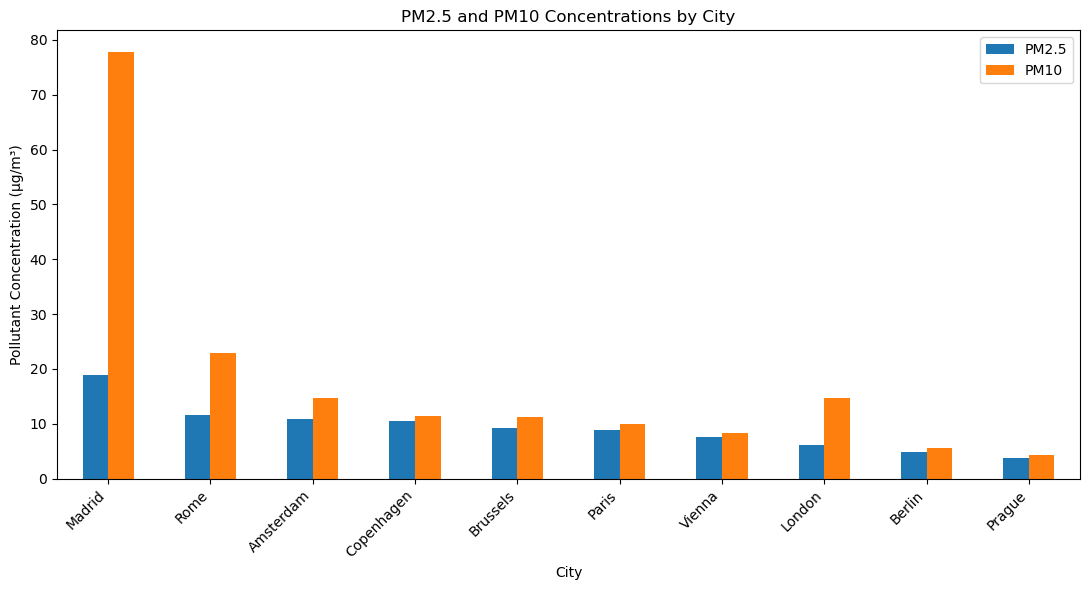

In [12]:
particle_df = df[
    ["city", "pm2_5", "pm10"]
].sort_values("pm2_5", ascending=False)

particle_df = particle_df.set_index("city")

particle_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("PM2.5 and PM10 Concentrations by City")
plt.xlabel("City")
plt.ylabel("Pollutant Concentration (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.legend(["PM2.5", "PM10"])
plt.tight_layout()

particle_figure = FIGURES_DIR / "particle_pollution_by_city.png"
plt.savefig(particle_figure, dpi=300, bbox_inches="tight")

plt.show()

## Relationships between weather and pollution

Correlation coefficients are used to describe whether two variables move together within the sample.

A positive correlation means that higher values of one variable tend to occur with higher values of the other. A negative correlation means that higher values of one variable tend to occur with lower values of the other.

Because the dataset contains only ten cities from one collection period, the correlations should be interpreted cautiously.

In [13]:
weather_pollution_columns = [
    "pm2_5",
    "pm10",
    "no2",
    "o3",
    "temperature_c",
    "humidity_percent",
    "pressure_hpa",
    "wind_speed_ms"
]

correlation_table = df[
    weather_pollution_columns
].corr().round(2)

correlation_table

,pm2_5,pm10,no2,o3,temperature_c,humidity_percent,pressure_hpa,wind_speed_ms
pm2_5,1.00,0.88,-0.21,-0.33,0.06,-0.02,0.33,-0.29
pm10,0.88,1.00,-0.35,-0.50,0.35,-0.36,0.23,-0.43
no2,-0.21,-0.35,1.00,0.18,-0.50,0.32,-0.35,-0.04
o3,-0.33,-0.50,0.18,1.00,0.29,-0.19,-0.63,0.43
temperature_c,0.06,0.35,-0.50,0.29,1.00,-0.96,-0.34,-0.18
humidity_percent,-0.02,-0.36,0.32,-0.19,-0.96,1.00,0.36,0.34
pressure_hpa,0.33,0.23,-0.35,-0.63,-0.34,0.36,1.00,-0.44
wind_speed_ms,-0.29,-0.43,-0.04,0.43,-0.18,0.34,-0.44,1.00


In [14]:
pm25_correlations = correlation_table["pm2_5"].sort_values(
    ascending=False
)

pm25_correlations

pm2_5               1.00
pm10                0.88
pressure_hpa        0.33
temperature_c       0.06
humidity_percent   -0.02
no2                -0.21
wind_speed_ms      -0.29
o3                 -0.33
Name: pm2_5, dtype: float64

## Finding 3: Wind speed and fine-particle pollution

Wind may disperse airborne pollutants. The following scatter plot examines whether cities with stronger wind had lower PM2.5 concentrations at the time of collection.

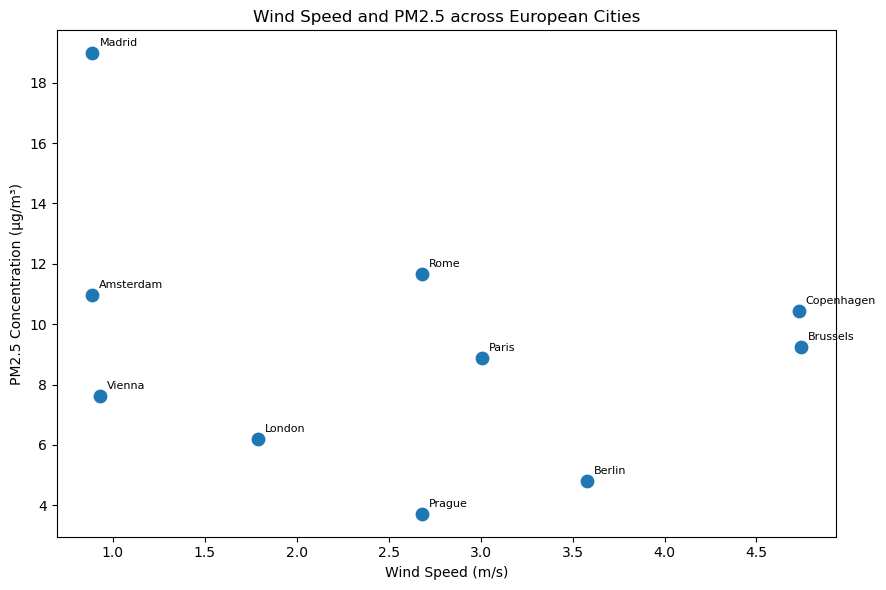

In [15]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["wind_speed_ms"],
    df["pm2_5"],
    s=80
)

for _, row in df.iterrows():
    plt.annotate(
        row["city"],
        (row["wind_speed_ms"], row["pm2_5"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Wind Speed and PM2.5 across European Cities")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.tight_layout()

wind_figure = FIGURES_DIR / "wind_speed_vs_pm25.png"
plt.savefig(wind_figure, dpi=300, bbox_inches="tight")

plt.show()

## Calculating exact correlations

In [16]:
wind_pm25_correlation = df[
    "wind_speed_ms"
].corr(df["pm2_5"])

print(
    "Correlation between wind speed and PM2.5:",
    round(wind_pm25_correlation, 2)
)

Correlation between wind speed and PM2.5: -0.29


## Humidity and fine-particle pollution

The next chart examines whether cities with higher humidity also had higher concentrations of PM2.5.

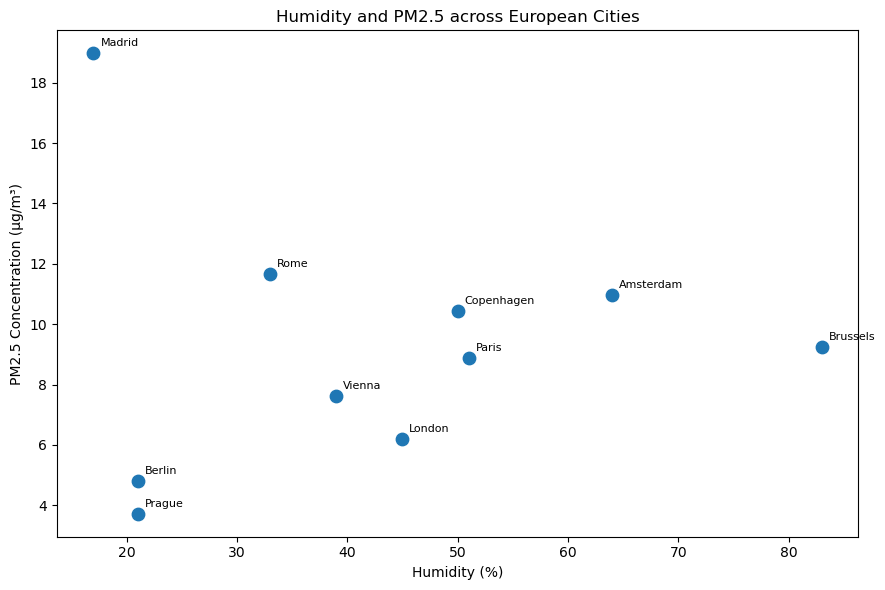

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["humidity_percent"],
    df["pm2_5"],
    s=80
)

for _, row in df.iterrows():
    plt.annotate(
        row["city"],
        (row["humidity_percent"], row["pm2_5"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Humidity and PM2.5 across European Cities")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.tight_layout()

humidity_figure = FIGURES_DIR / "humidity_vs_pm25.png"
plt.savefig(humidity_figure, dpi=300, bbox_inches="tight")

plt.show()

In [19]:
humidity_pm25_correlation = df[
    "humidity_percent"
].corr(df["pm2_5"])

print(
    "Correlation between humidity and PM2.5:",
    round(humidity_pm25_correlation, 2)
)

Correlation between humidity and PM2.5: -0.02


## Temperature and fine-particle pollution

This chart examines the relationship between temperature and PM2.5 in the selected cities.

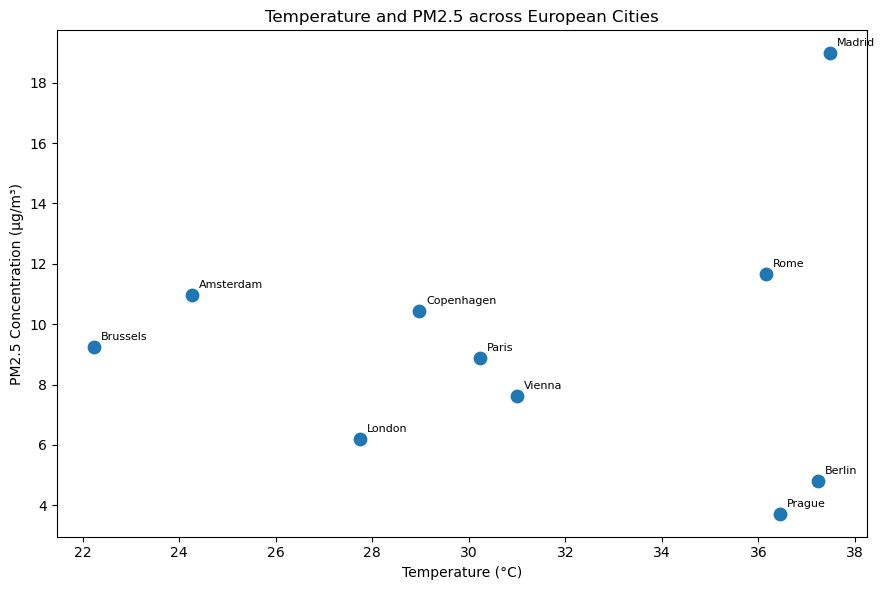

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["temperature_c"],
    df["pm2_5"],
    s=80
)

for _, row in df.iterrows():
    plt.annotate(
        row["city"],
        (row["temperature_c"], row["pm2_5"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Temperature and PM2.5 across European Cities")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.tight_layout()

temperature_figure = FIGURES_DIR / "temperature_vs_pm25.png"
plt.savefig(temperature_figure, dpi=300, bbox_inches="tight")

plt.show()

In [21]:
temperature_pm25_correlation = df[
    "temperature_c"
].corr(df["pm2_5"])

print(
    "Correlation between temperature and PM2.5:",
    round(temperature_pm25_correlation, 2)
)

Correlation between temperature and PM2.5: 0.06


## Identifying highest and lowest values

In [22]:
highest_pm25_city = df.loc[df["pm2_5"].idxmax()]
lowest_pm25_city = df.loc[df["pm2_5"].idxmin()]

highest_pm10_city = df.loc[df["pm10"].idxmax()]
lowest_pm10_city = df.loc[df["pm10"].idxmin()]

print(
    "Highest PM2.5:",
    highest_pm25_city["city"],
    "-",
    highest_pm25_city["pm2_5"]
)

print(
    "Lowest PM2.5:",
    lowest_pm25_city["city"],
    "-",
    lowest_pm25_city["pm2_5"]
)

print(
    "Highest PM10:",
    highest_pm10_city["city"],
    "-",
    highest_pm10_city["pm10"]
)

print(
    "Lowest PM10:",
    lowest_pm10_city["city"],
    "-",
    lowest_pm10_city["pm10"]
)

Highest PM2.5: Madrid - 18.97
Lowest PM2.5: Prague - 3.72
Highest PM10: Madrid - 77.85
Lowest PM10: Prague - 4.37


## Results summary table

In [23]:
results_summary = df[
    [
        "city",
        "aqi_category",
        "pm2_5",
        "pm10",
        "temperature_c",
        "humidity_percent",
        "wind_speed_ms"
    ]
].sort_values("pm2_5", ascending=False)

results_summary.reset_index(drop=True)

,city,aqi_category,pm2_5,pm10,temperature_c,humidity_percent,wind_speed_ms
0,Madrid,Moderate,18.97,77.85,37.48,17,0.89
1,Rome,Moderate,11.66,22.97,36.16,33,2.68
2,Amsterdam,Moderate,10.96,14.68,24.26,64,0.89
3,Copenhagen,Moderate,10.43,11.48,28.97,50,4.73
4,Brussels,Fair,9.24,11.28,22.23,83,4.74
5,Paris,Moderate,8.87,9.97,30.24,51,3.01
6,Vienna,Moderate,7.62,8.37,31.00,39,0.93
7,London,Fair,6.21,14.71,27.75,45,1.79
8,Berlin,Moderate,4.79,5.53,37.23,21,3.58
9,Prague,Moderate,3.72,4.37,36.45,21,2.68


## Save the table

In [24]:
results_output = (
    PROCESSED_DATA_DIR /
    "city_air_quality_results.csv"
)

results_summary.to_csv(
    results_output,
    index=False
)

print(results_output.resolve())

/files/assignments/final-project/data/processed/city_air_quality_results.csv


# Conclusion

This project investigated how air quality varied across ten major European cities and whether weather conditions were associated with worse pollution.

## Finding 1: Air quality varied across cities

Madrid had the highest PM2.5 concentration in the dataset, at **18.97 µg/m³**. Prague had the lowest PM2.5 concentration, at **3.72 µg/m³**.

Although most cities were classified in the broad **Moderate** AQI category, their individual pollution levels differed considerably. For example, Madrid and Prague were both classified as Moderate, even though Madrid’s PM2.5 concentration was more than five times higher than Prague’s. This shows that pollutant measurements such as PM2.5 provide more detail than the AQI category alone.

## Finding 2: Madrid had unusually high particle pollution

Madrid had the highest levels of both PM2.5 and PM10. Its PM10 concentration was **77.85 µg/m³**, which was substantially higher than the value recorded for every other city.

Rome had the second-highest PM2.5 concentration at **11.66 µg/m³**, while Amsterdam and Copenhagen also recorded values above **10 µg/m³**. Prague and Berlin had the lowest PM2.5 values, at **3.72 µg/m³** and **4.79 µg/m³**, respectively.

PM2.5 and PM10 were strongly positively correlated in this sample, with a correlation of approximately **0.88**. This suggests that cities with higher fine-particle pollution also tended to have higher concentrations of larger particles.

## Finding 3: Weather conditions had weak relationships with PM2.5

The correlation between wind speed and PM2.5 was approximately **-0.29**. This indicates a weak negative relationship, meaning that cities with stronger winds tended to have slightly lower PM2.5 concentrations. This pattern may be consistent with wind dispersing pollution, but the relationship was not strong.

The correlation between humidity and PM2.5 was approximately **-0.02**, showing almost no linear relationship in this dataset.

The correlation between temperature and PM2.5 was approximately **0.06**, which also indicates almost no linear relationship.

Overall, wind speed showed the clearest relationship with PM2.5, but it was still relatively weak. Temperature and humidity did not appear to explain much of the variation in pollution across the selected cities.

## Limitations

The dataset contains only one observation for each of ten cities. Air quality and weather can change throughout the day and across different seasons. Pollution levels may also be affected by traffic, industry, geography, local emissions, and the exact location where the measurement was taken.

Madrid’s particularly high PM10 value may have strongly influenced the comparisons and correlation results. The small sample size means that the findings should be interpreted as a snapshot rather than a complete description of typical air quality in each city.

A stronger future study would collect repeated observations for each city over several days or weeks. This would make it possible to compare average pollution levels and examine weather relationships over time.

## Overall answer

Air quality varied substantially across the ten European cities, particularly when comparing PM2.5 and PM10 concentrations. Madrid recorded the highest particle pollution, while Prague and Berlin recorded the lowest PM2.5 levels.

Weather conditions showed only limited associations with pollution in this snapshot. Higher wind speeds were weakly associated with lower PM2.5 concentrations, while temperature and humidity showed almost no relationship. The results therefore suggest that city-level differences and other local factors may have been more important than the weather measurements included in this dataset.

## Check that the files saved correctly

In [25]:
saved_figures = list(FIGURES_DIR.glob("*.png"))

for figure in saved_figures:
    print(figure.name)

temperature_vs_pm25.png
particle_pollution_by_city.png
humidity_vs_pm25.png
pm25_by_city.png
aqi_by_city.png
pm10_by_city.png
wind_speed_vs_pm25.png


## Analysis summary

This notebook compared air quality across ten European cities using AQI, PM2.5, PM10, and other pollutant measurements.

It also explored the relationships between PM2.5 and three weather conditions:

- wind speed
- humidity
- temperature

The analysis found meaningful variation between cities, although the broad AQI categories sometimes concealed differences in individual pollutant concentrations.

All major figures were saved in `docs/figures` for use on the project website. The results should be interpreted as a snapshot because the dataset contains one collection period.